In [1]:
!pip install -q pydicom
!pip install -q opencv-python

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 32.9 MB/s eta 0:00:0000:0100:01


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
!ls -ltr /content/drive/MyDrive/chest-data/stage_2_train_images/02363fdb-4cd0-4631-b3d8-7a10fddffa28.dcm

-rw------- 1 root root 102110 Dec 11  2019 /content/drive/MyDrive/chest-data/stage_2_train_images/02363fdb-4cd0-4631-b3d8-7a10fddffa28.dcm


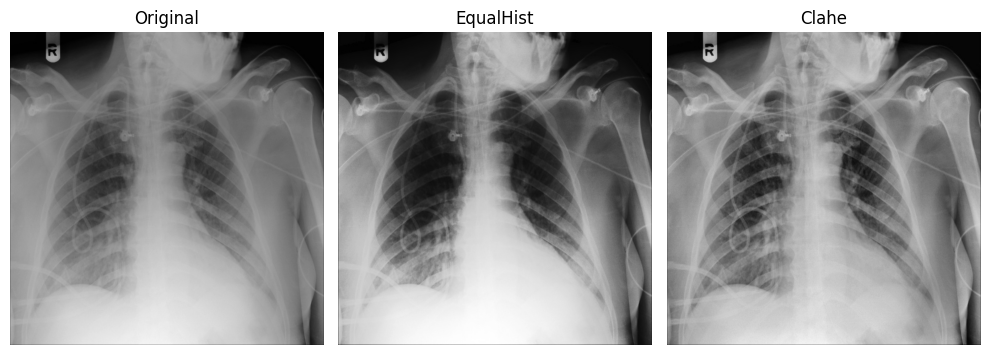

In [15]:
from matplotlib import axes

import pydicom
import matplotlib.pyplot as plt
import cv2
import numpy as np

dicom_path = '/content/drive/MyDrive/chest-data/stage_2_train_images/02363fdb-4cd0-4631-b3d8-7a10fddffa28.dcm'
def fetch_img_array(dicom_path):
  ds = pydicom.dcmread(dicom_path)
  img = ds.pixel_array.astype(float)
  # FIX: Invert if the image is 'Monochrome1' (standard in some X-ray machines)
  if ds.PhotometricInterpretation == "MONOCHROME1":
      img = np.amax(img) - img
  img = (np.maximum(img, 0) / img.max()) * 255.0  
  img = np.uint8(img)
  return img
img = fetch_img_array(dicom_path)

original_resize = cv2.resize(img,(640,640))
cv2.imwrite('/content/drive/MyDrive/chest-data/02363fdb-4cd0-4631-b3d8-7a10fddffa28_original_resize.jpg',original_resize)

img1 = cv2.equalizeHist(img)
img_resized1 = cv2.resize(img1, (640,640))
cv2.imwrite('/content/drive/MyDrive/chest-data/02363fdb-4cd0-4631-b3d8-7a10fddffa28_equalHist.jpg', img_resized1)

clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
cl_img = clahe.apply(img)
img_resized2 = cv2.resize(cl_img, (640,640))
# Save or display results
cv2.imwrite('/content/drive/MyDrive/chest-data/02363fdb-4cd0-4631-b3d8-7a10fddffa28_clahe_xray.jpg', img_resized2)


# Load images
img1 = cv2.imread('/content/drive/MyDrive/chest-data/02363fdb-4cd0-4631-b3d8-7a10fddffa28_original_resize.jpg')
img2 = cv2.imread('/content/drive/MyDrive/chest-data/02363fdb-4cd0-4631-b3d8-7a10fddffa28_equalHist.jpg')
img3 = cv2.imread('/content/drive/MyDrive/chest-data/02363fdb-4cd0-4631-b3d8-7a10fddffa28_clahe_xray.jpg')



img1_rgb = cv2.cvtColor(img1, cv2.COLOR_BGR2RGB)
img2_rgb = cv2.cvtColor(img2, cv2.COLOR_BGR2RGB)
img3_rgb = cv2.cvtColor(img3, cv2.COLOR_BGR2RGB)

fig, (ax1, ax2,ax3) = plt.subplots(1, 3, figsize=(10, 5))

# Plot images on each axis
ax1.imshow(img1_rgb)
ax1.set_title("Original")
ax1.axis('off') # Hide axes ticks

ax2.imshow(img2_rgb)
ax2.set_title("EqualHist")
ax2.axis('off')

ax3.imshow(img3_rgb)
ax3.set_title("Clahe")
ax3.axis('off')

plt.tight_layout() # Prevent overlapping
plt.show()






In [9]:
import pydicom
import cv2
import numpy as np
import os

def process_dicom(dicom_path, save_path, size=(640, 640)):
    # 1. Load the DICOM file and extract the raw pixel array
    ds = pydicom.dcmread(dicom_path)
    img = ds.pixel_array.astype(float)

    # FIX: Invert if the image is 'Monochrome1' (standard in some X-ray machines)
    if ds.PhotometricInterpretation == "MONOCHROME1":
        img = np.amax(img) - img

    # 2. Rescale pixel values (Medical images often have > 8-bit depth)
    # This maps the image to a 0-255 range for standard CNNs
    img = (np.maximum(img, 0) / img.max()) * 255.0
    img = np.uint8(img)

    # 3. Histogram Equalization (Improves contrast for pneumonia detection)
    # img = cv2.equalizeHist(img)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    cl_img = clahe.apply(img)

    # 4. Resize and Save to your Google Drive
    img_resized = cv2.resize(cl_img, size)
    cv2.imwrite(save_path, img_resized)



In [44]:
import pandas as pd
df = pd.read_csv('/content/drive/MyDrive/chest-data/stage_2_train_labels.csv')
df_cleaned = df.drop_duplicates(subset=['patientId'], keep='first')
count = 0
for i in df_cleaned['patientId'].head(2000):
  dicom_path = f"/content/drive/MyDrive/chest-data/stage_2_train_images/{i}.dcm"
  if df_cleaned[df_cleaned['patientId'] == i]['Target'].values[0] == 1:
    save_path = f"/content/drive/MyDrive/chest-data/first_2kjpg_images/class1/{i}.jpg"
  else:
    save_path = f"/content/drive/MyDrive/chest-data/first_2kjpg_images/class0/{i}.jpg"

  process_dicom(dicom_path, save_path)
  count += 1
  if count % 100 == 0:
    print(f"Processed {count} images")
print("Finished conversion of first 2000 dcm images to JPG format")


Processed 100 images
Processed 200 images
Processed 300 images
Processed 400 images
Processed 500 images
Processed 600 images
Processed 700 images
Processed 800 images
Processed 900 images
Processed 1000 images
Processed 1100 images
Processed 1200 images
Processed 1300 images
Processed 1400 images
Processed 1500 images
Processed 1600 images
Processed 1700 images
Processed 1800 images
Processed 1900 images
Processed 2000 images
Finished conversion of first 2000 dcm images to JPG format


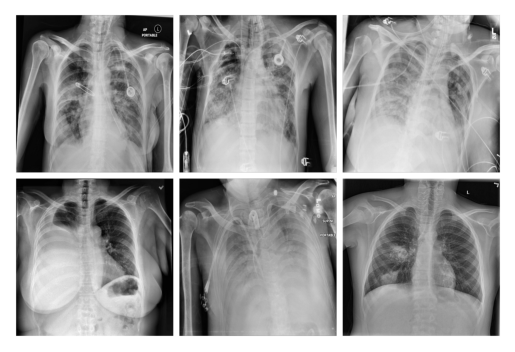

In [48]:
#check whether images have been processed as expected 
import torch
import torchvision
from torchvision.io import read_image
from torchvision.utils import make_grid
import os
import random
import matplotlib.pyplot as plt

# read images from the folder
folder = '/content/drive/MyDrive/chest-data/first_2kjpg_images/class1'
filename_list = os.listdir(folder)

# Pick 6 random images from the list
num_images_to_display = 6
if len(filename_list) >= num_images_to_display:
    selected_filenames = random.sample(filename_list, num_images_to_display)
else:
    # If there are fewer than 6 images, display all of them
    selected_filenames = filename_list

images_to_display = []
for filename in selected_filenames:
    images_to_display.append(read_image(f'{folder}/{filename}'))

# make grid from the input images
Grid = make_grid(images_to_display, nrow=3, padding=25, pad_value=255) # Increased padding and set pad_value to white

# display result
img = torchvision.transforms.ToPILImage()(Grid)
plt.imshow(img)
plt.axis('off')
plt.show()

In [49]:
import os
import pandas as pd
from sklearn.model_selection import train_test_split
import shutil

# Paths based on your previous snippet
base_path = "/content/drive/MyDrive/chest-data/first_2kjpg_images"
class0_dir = os.path.join(base_path, "class0")
class1_dir = os.path.join(base_path, "class1")

# Gather all filenames and map them to their label
data = []
for filename in os.listdir(class0_dir):
    if filename.endswith('.jpg'):
        data.append({'filepath': os.path.join(class0_dir, filename), 'filename': filename, 'label': 0})

for filename in os.listdir(class1_dir):
    if filename.endswith('.jpg'):
        data.append({'filepath': os.path.join(class1_dir, filename), 'filename': filename, 'label': 1})

df_images = pd.DataFrame(data)
print(f"Total images found: {len(df_images)}")
print(df_images['label'].value_counts(normalize=True))

Total images found: 2000
label
0    0.673
1    0.327
Name: proportion, dtype: float64


In [50]:
# 1. Split off the Test set (15% of total)
train_val, test = train_test_split(
    df_images, 
    test_size=0.15, 
    stratify=df_images['label'], 
    random_state=42
)

# 2. Split the remainder into Train (70% of total) and Validation (15% of total)
# 0.15 / 0.85 is roughly 17.6% of the remaining 85%
train, val = train_test_split(
    train_val, 
    test_size=0.176, 
    stratify=train_val['label'], 
    random_state=42
)

print(f"Train size: {len(train)} | Val size: {len(val)} | Test size: {len(test)}")


Train size: 1400 | Val size: 300 | Test size: 300


In [51]:
def create_split_folders(df_split, split_name):
    for _, row in df_split.iterrows():
        # Define destination: e.g., .../first_2kjpg_images/train/Opacity/patientId.jpg
        class_folder = "Opacity" if row['label'] == 1 else "Normal"
        dest_dir = os.path.join(base_path, split_name, class_folder)
        
        # Create folder if it doesn't exist
        os.makedirs(dest_dir, exist_ok=True)
        
        # Move the file from its current class0/class1 folder
        shutil.move(row['filepath'], os.path.join(dest_dir, row['filename']))

# Execute the moves
create_split_folders(train, "train")
create_split_folders(val, "val")
create_split_folders(test, "test")

print("All files successfully moved into stratified train, val, and test folders!")


All files successfully moved into stratified train, val, and test folders!


In [54]:
!ls -ltr /content/drive/MyDrive/chest-data/first_2kjpg_images/train/Opacity/ | wc -l
!ls -ltr /content/drive/MyDrive/chest-data/first_2kjpg_images/train/Normal/ | wc -l
!ls -ltr /content/drive/MyDrive/chest-data/first_2kjpg_images/val/Opacity/ | wc -l
!ls -ltr /content/drive/MyDrive/chest-data/first_2kjpg_images/val/Normal/ | wc -l
!ls -ltr /content/drive/MyDrive/chest-data/first_2kjpg_images/test/Opacity/ | wc -l
!ls -ltr /content/drive/MyDrive/chest-data/first_2kjpg_images/test/Normal/ | wc -l

459
943
99
203
99
203


In [56]:
#To address the class imbalance in training set , penalize the model forcing it to pay closer attention to pneumonia features
import os
import torch
import torch.nn as nn
from torchvision import datasets, models, transforms
from torch.utils.data import DataLoader

# 1. Setup Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# 2. Count training images to calculate weights
train_dir = "/content/drive/MyDrive/chest-data/first_2kjpg_images/train"
num_normal = len(os.listdir(os.path.join(train_dir, "Normal")))
num_opacity = len(os.listdir(os.path.join(train_dir, "Opacity")))
total_train = num_normal + num_opacity

# Calculate inverse frequency weights
weight_normal = total_train / (2 * num_normal)
weight_opacity = total_train / (2 * num_opacity)
class_weights = torch.tensor([weight_normal, weight_opacity], dtype=torch.float).to(device)

print(f"Normal: {num_normal} | Opacity: {num_opacity}")
print(f"Loss weights -> Normal: {weight_normal:.2f}, Opacity: {weight_opacity:.2f}")


Using device: cpu
Normal: 942 | Opacity: 458
Loss weights -> Normal: 0.74, Opacity: 1.53
